Prblem Statement: We want to **recognize** for **hand writen digit** dataset so that we can **read **hand writen digits, by building a model that read "**Cheque**"

Metrics: I want to success (85<accuracy) and 90% at least **Cheque** will be reading by computers

Data need: Normalization,Reshaping,Encode Labels

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import pandas as pd
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout,RandomRotation,RandomZoom,RandomTranslation
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping,ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import os
import matplotlib.pyplot as plt
import seaborn as sns
#read files
df= pd.read_csv("/content/train.csv")
# Normalization and Spliting
y=df["label"].values
x=df.drop(labels=["label"],axis=1)

x= x / 255

xfulltrain, x_test, yfulltrain, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

x_train, x_val, y_train, y_val = train_test_split(
    xfulltrain, yfulltrain, test_size=0.2, random_state=42, stratify=yfulltrain
)

#Reshape to (28,28)
x_train = x_train.values.reshape(-1, 28, 28, 1)
x_val = x_val.values.reshape(-1, 28, 28, 1)
x_test = x_test.values.reshape(-1, 28, 28, 1)

#Sequential
model=keras.Sequential([
    #To change pictures case
    RandomRotation(factor=0.1, input_shape=(28, 28, 1)),
    RandomZoom(height_factor=0.1),
    RandomTranslation(height_factor=0.1, width_factor=0.1),

    layers.Conv2D(64,3,activation="relu",input_shape=(28,28,1)),
    layers.MaxPooling2D(),
    layers.Conv2D(128,3,activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256,activation="relu"),
    Dropout(0.4),# to protect the model from overfitting
    layers.Dense(10,activation="softmax"),
])


#Schedule the LR if the val_loss dosen't change for 3 epochs the LR will be the half the last one
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1)

#Early Stopping if the val_loss dosen't change for 7 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)

#Save the best epoch on training
checkpoint=ModelCheckpoint("best_cnn.keras", save_best_only=True)

#Compile The Metrics
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
history= model.fit(x_train , y_train , validation_data=(x_val,y_val), epochs=50 , batch_size=32,callbacks=[reduce_lr,early_stop,checkpoint])
#To use history variable any time and quickly
np.save('my_history.npy', history.history)


os.makedirs('models', exist_ok=True)
model.save("models/mnist_cnn.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
840/840 ━━━━━━━━━━━━━━━━━━━━ 70s 80ms/step - accuracy: 0.8197 - loss: 0.5565 - val_accuracy: 0.9726 - val_loss: 0.0779 - learning_rate: 0.0010
Epoch 2/50
840/840 ━━━━━━━━━━━━━━━━━━━━ 68s 81ms/step - accuracy: 0.9314 - loss: 0.2205 - val_accuracy: 0.9777 - val_loss: 0.0731 - learning_rate: 0.0010
Epoch 3/50
840/840 ━━━━━━━━━━━━━━━━━━━━ 66s 78ms/step - accuracy: 0.9467 - loss: 0.1737 - val_accuracy: 0.9842 - val_loss: 0.0479 - learning_rate: 0.0010
Epoch 4/50
840/840 ━━━━━━━━━━━━━━━━━━━━ 66s 79ms/step - accuracy: 0.9574 - loss: 0.1403 - val_accuracy: 0.9827 - val_loss: 0.0536 - learning_rate: 0.0010
Epoch 5/50
840/840 ━━━━━━━━━━━━━━━━━━━━ 65s 78ms/step - accuracy: 0.9610 - loss: 0.1263 - val_accuracy: 0.9856 - val_loss: 0.0512 - learning_rate: 0.0010
Epoch 6/50
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9634 - loss: 0.1176
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
840/840 ━━━━━━━━━━━━━━━━━━━━ 63s 74ms/step - accuracy: 0.9653 - los

### Load the best model

To ensure we are using the best performing model based on validation loss, we can reload the model saved by `ModelCheckpoint`.

In [8]:
from tensorflow.keras.models import load_model

# Load the best model saved during training
model = load_model('best_cnn.keras')

263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step
Test Acuuracy = 99.25% 

Classification report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       827
           1       1.00      0.99      1.00       937
           2       0.99      0.99      0.99       835
           3       0.99      0.99      0.99       870
           4       0.99      1.00      0.99       814
           5       0.99      0.99      0.99       759
           6       0.99      1.00      1.00       827
           7       0.99      0.99      0.99       880
           8       0.99      0.99      0.99       813
           9       0.99      0.99      0.99       838

    accuracy                           0.99      8400
   macro avg       0.99      0.99      0.99      8400
weighted avg       0.99      0.99      0.99      8400



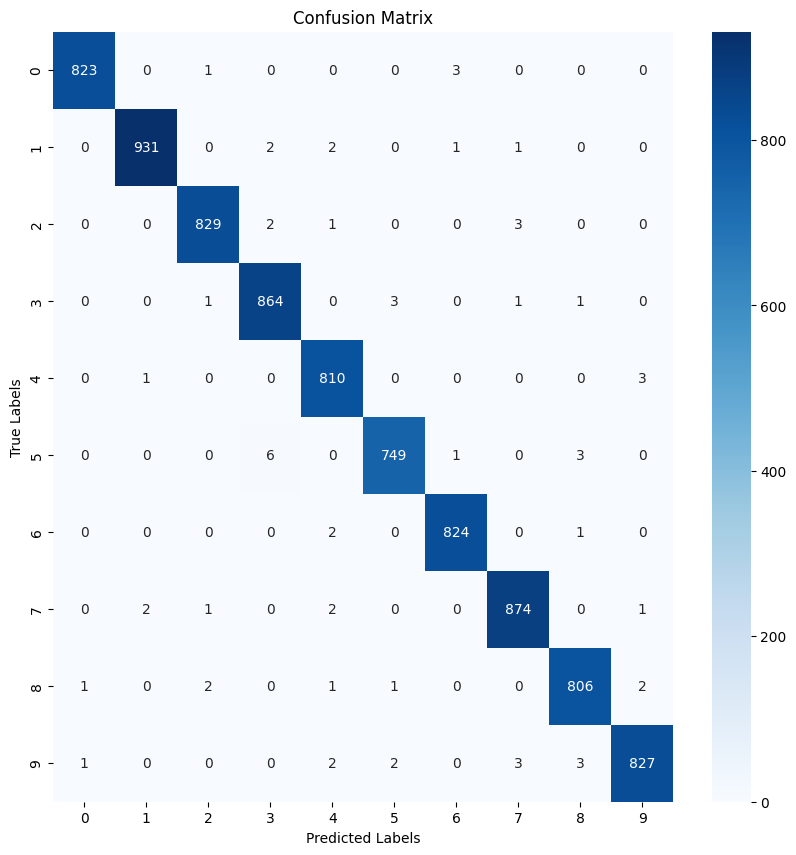

Count of numbers that the model pridected false63


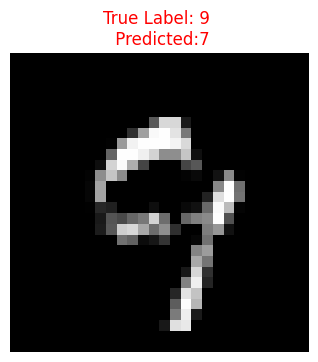

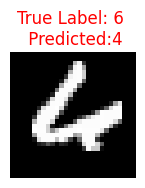

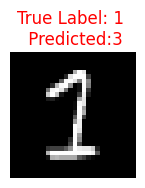

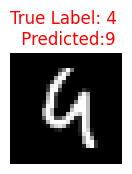

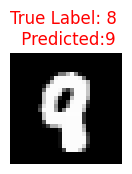

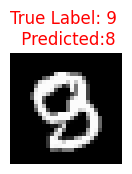

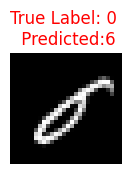

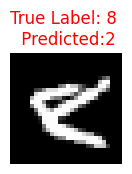

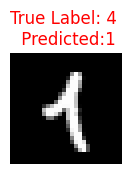

In [9]:
y_pred=model.predict(x_test)
y_pred_classes=np.argmax(y_pred, axis=1)
y_true=y_test

target_names=[str(i) for i in range(10)]

#Test Accuracy
test_loss, test_accuracy= model.evaluate(x_test, y_test, verbose=0)
print(f"Test Acuuracy = {test_accuracy*100:.2f}% \n")

# Classification Report
print(f"Classification report: \n {classification_report(y_true, y_pred_classes, target_names= target_names)}")

# Confusion Matrix
cm= confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)

plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.title('Confusion Matrix')

os.makedirs('reports', exist_ok=True)
plt.savefig('reports/confusion matrix.png', dpi=300)
plt.show()

# Error Analysis
error_indices=np.where(y_pred_classes != y_true)
print(f"Count of numbers that the model pridected false{len(error_indices[0])}")

plt.figure(figsize=(10, 10))
for i,idx in enumerate(error_indices[0][:9]): # Access the actual indices from the tuple
  plt.subplot(3,3,i+1)
  plt.imshow(x_test[idx].reshape(28, 28), cmap='gray') # Show the original picture with original shape gray color
  plt.axis('off')

  actual_num=y_true[idx]
  predicted_num=y_pred_classes[idx]

  plt.title(f"True Label: {actual_num} \n Predicted:{predicted_num}", color='red', fontsize=12)

  plt.tight_layout()
  plt.show()

Count of numbers that the model pridected false79

Confuesd Numbers:

True --> Predicted

  9  -->   7

  6  -->   4

  1  -->   3

  4  -->   9

  8  -->   9

  9  -->   8

  0  -->   6

  8  -->   2

  4  -->   1




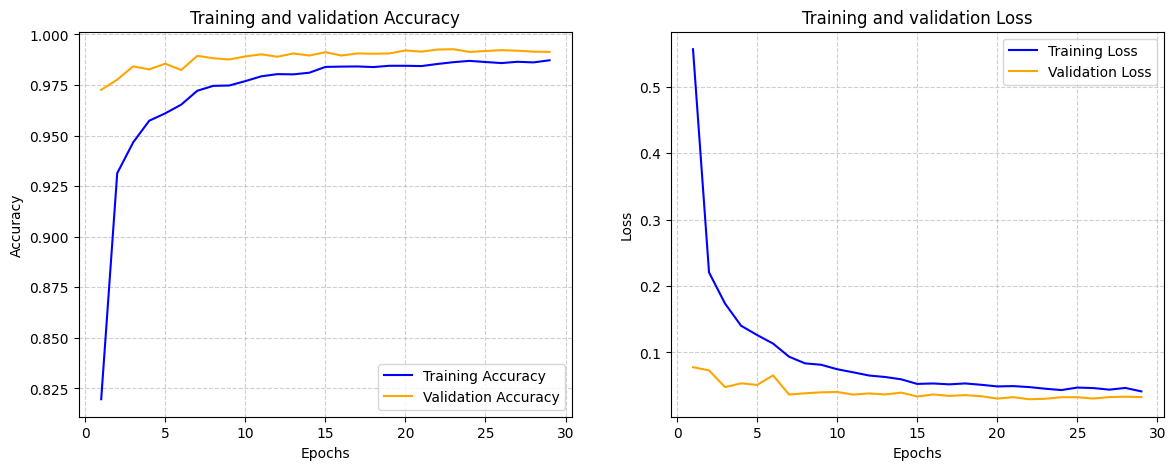

In [10]:
acc=history.history["accuracy"]
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

epoch_range= range(1, len(acc)+1)

plt.figure(figsize=(14,5))

#Accuracy Plot
plt.subplot(1,2,1)
plt.plot(epoch_range, acc, label='Training Accuracy', color='blue')
plt.plot(epoch_range, val_acc, label='Validation Accuracy', color='orange')
plt.title("Training and validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)#Grid for best vision

#Loss Plot
plt.subplot(1,2,2)
plt.plot(epoch_range, loss, label='Training Loss', color='blue')
plt.plot(epoch_range, val_loss, label='Validation Loss', color='orange')
plt.title("Training and validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)#Grid for best vision

#To save it at reports file
plt.savefig('reports/learning_curve.png', dpi=300)

plt .show()